## Preliminaries

In [1]:
import pandas as pd
import numpy as np

In [2]:
# =========================================================
# LOAD PREDICTIONS
# =========================================================

predictions = pd.read_csv("predictions/pm100/predictions_s.csv")

In [3]:
def load_swf(filepath, sim_start_time):
    df = pd.read_csv(filepath, sep=';')

    # Convert timestamps to seconds from simulation start
    df["start_time"] = pd.to_datetime(df["start_time"]).astype("int64") // 10**9
    df["end_time"] = pd.to_datetime(df["end_time"]).astype("int64") // 10**9

    df["start_time"] -= sim_start_time
    df["end_time"] -= sim_start_time

    diff = min(df["start_time"])
    
    df["end_time"] -= diff
    df["start_time"] -= diff
    
    return df

In [4]:
TOTAL_NODES = 980

def node_utilization(df):

    # ----------------------------------------
    # Preprocessing
    # ----------------------------------------
    df = df.sort_values("start_time").copy()

    # ----------------------------------------
    # UTILIZATION EVENTS
    # ----------------------------------------
    events = []  # (time, delta_nodes)

    for _, row in df.iterrows():
        events.append((row["start_time"], +row["nodes"]))
        events.append((row["end_time"], -row["nodes"]))

    # ----------------------------------------
    # NODE UTILIZATION (event sweep)
    # ----------------------------------------
    events.sort(key=lambda x: x[0])

    times = []
    utilizations = []

    cores = TOTAL_NODES
    
    current_nodes = 0
    last_time = None

    for time, delta in events:

        if last_time is not None and time != last_time:
            # Record utilization for previous interval
            utilization = current_nodes / cores
            times.append(last_time)
            utilizations.append(utilization)

        current_nodes += delta
        last_time = time

    # Add final point
    if last_time is not None:
        times.append(last_time)
        utilizations.append(current_nodes / cores)

    return {
        "time": np.array(times),
        "node_utilization": np.array(utilizations)
    }

def queue_size_over_time(df):
    df = df.copy()

    events = []  # (time, delta_queue)

    # ----------------------------------------
    # Real queue events
    # ----------------------------------------
    for _, row in df.iterrows():
        if row["wtime"] > 0:
            events.append((row["submit_time"], +1))
            events.append((row["start_time"], -1))

    # ----------------------------------------
    # Boundary conditions
    # ----------------------------------------
    t_start = df["submit_time"].min()
    t_end = df["end_time"].max()

    # Add dummy events to enforce boundaries
    events.append((t_start, 0))
    events.append((t_end, 0))

    # ----------------------------------------
    # Sort events
    # ----------------------------------------
    events.sort(key=lambda x: x[0])

    times = []
    queue_sizes = []

    current_queue = 0
    last_time = None

    # ----------------------------------------
    # Event sweep
    # ----------------------------------------
    for time, delta in events:
        if last_time is not None and time != last_time:
            times.append(last_time)
            queue_sizes.append(current_queue)

        current_queue += delta
        last_time = time

    # Add final point
    if last_time is not None:
        times.append(last_time)
        queue_sizes.append(current_queue)

    return {
        "time": np.array(times),
        "queue_size": np.array(queue_sizes)
    }

In [47]:
import matplotlib.pyplot as plt

def plot_utilization(sim_result, title="Node Utilization"):
    plt.figure(figsize=(10, 5))
    
    plt.plot(sim_result["time"]/max(sim_result["time"])*100, sim_result["node_utilization"]*100)
    
    plt.xlabel("Makespan (%)")
    plt.ylabel("Utilization (%)")
    plt.title(title)
    
    plt.grid()
    plt.show()

def plot_queue(sim_result, title="Queue Size"):
    plt.figure(figsize=(10, 5))
    
    plt.plot(sim_result["time"]/max(sim_result["time"])*100, sim_result["queue_size"])
    
    plt.xlabel("Makespan (%)")
    plt.ylabel("Queue Size")
    plt.title(title)
    
    plt.grid()
    plt.show()

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

def plot_utilization_with_queue_bands(util_result, queue_result, title="Utilization vs Queue", image_path=""):
    # Increased top padding to give room for the title and outside legend
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.subplots_adjust(top=0.99) 

    # Use actual time (e.g., in hours) instead of normalization percentage
    t_util = util_result["time"] / 3600
    t_queue = queue_result["time"] / 3600

    max_duration_hours = max(t_util)

    util = util_result["node_utilization"] * 100
    queue = queue_result["queue_size"]

    # ----------------------------------------
    # Background bands (queue state)
    # ----------------------------------------
    for i in range(len(t_queue) - 1):
        t_start = t_queue[i]
        t_end = t_queue[i + 1]

        color = "mistyrose" if queue[i] > 0 else "green"
        alpha = 0.15 if queue[i] > 0 else 0.1

        ax.axvspan(t_start, t_end, color=color, alpha=alpha)

    # ----------------------------------------
    # Utilization line (Dark Gray)
    # ----------------------------------------
    util_line, = ax.plot(t_util, util, color="black", linewidth=0.7, label="Utilization (%)")

    # ----------------------------------------
    # Labels, Title & Dynamic Ticks
    # ----------------------------------------
    ax.set_xlabel("Workload Execution Time (Hours)", fontsize=14)
    ax.set_ylabel("Utilization (%)", fontsize=14)
    ax.set_ylim(0, 100)
    
    # Place title slightly higher to accommodate the legend below it
    ax.set_title(title, fontsize=18, y=1.10, pad=15)

    # Dynamic tick intervals based on total duration logic:
    if max_duration_hours <= 26:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(6))     # Every 6 hours
    elif max_duration_hours <= 168:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(24))    # Every 1 day
    elif max_duration_hours <= 720:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(168))   # Every 1 week
    else:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(720))   # Every 1 month

    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True)

    # Custom legend with matching patch styling + utilization line
    legend_elements = [
        # util_line,
        Patch(facecolor='green', alpha=0.1, edgecolor='none', label='Empty Queue'),
        Patch(facecolor='lightcoral', alpha=0.15, edgecolor='none', label='Non-Empty Queue')
    ]
    
    # Legend centered just below the title, outside the plot area
    ax.legend(
        handles=legend_elements, 
        loc="lower center", 
        bbox_to_anchor=(0.5, 1.02), 
        fontsize=12, 
        frameon=True,
        ncol=2  # Arranges items horizontally in a single row
    )
    
    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {image_path}")
        
    plt.show()


def plot_utilization_with_queue_bands(util_result, queue_result, title="Utilization vs Queue", image_path=""):
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.subplots_adjust(top=0.90) 

    # Use actual time (e.g., in hours) instead of normalization percentage
    t_util = util_result["time"] / 3600
    t_queue = queue_result["time"] / 3600

    max_duration_hours = max(t_util)

    util = util_result["node_utilization"] * 100
    queue = queue_result["queue_size"]

    # ----------------------------------------
    # Background bands (queue state)
    # ----------------------------------------
    for i in range(len(t_queue) - 1):
        t_start = t_queue[i]
        t_end = t_queue[i + 1]

        # Only plot red band when queue > 0; empty queue intervals are skipped (remain white)
        if queue[i] > 0:
            ax.axvspan(t_start, t_end, color="#FF2E2E", alpha=0.30)

    # ----------------------------------------
    # Utilization line
    # ----------------------------------------
    util_line, = ax.plot(t_util, util, linewidth=0.8)

    # ----------------------------------------
    # Labels, Title & Dynamic Ticks
    # ----------------------------------------
    ax.set_xlabel("Workload Execution Time (Hours)", fontsize=14)
    ax.set_ylabel("Utilization (%)", fontsize=14)
    ax.set_ylim(0, 100)
    
    ax.set_title(title, fontsize=18, pad=15)

    # Dynamic tick intervals based on total duration logic:
    if max_duration_hours <= 26:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(6))   # Every 6 hours
    elif max_duration_hours <= 168:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(24))    # Every 1 day
    elif max_duration_hours <= 720:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(168))   # Every 1 week
    else:
        ax.xaxis.set_major_locator(ticker.MultipleLocator(720))   # Every 1 month

    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True)
    
    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {image_path}")
        
    plt.show()

def plot_utilization_all(util_list, labels, title="Node Utilization", image_path=""):
    plt.figure(figsize=(10, 5))
    
    for sim_result, label in zip(util_list, labels):
        plt.plot(
            sim_result["time"]/max(sim_result["time"])*100,
            sim_result["node_utilization"]*100,
            label=label
        )
    
    plt.xlabel("Makespan (%)")
    plt.ylabel("Utilization (%)")
    plt.title(title)
    
    plt.legend()
    plt.grid()

    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
    
    plt.show()

## Heavy

In [31]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/pm100/pm100_1800_1.swf',
    header=None,
    sep='\t'
)

workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memory", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

workload_df.columns = workload_column_names

# Rename for consistency
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})

### SJF

In [32]:
# =========================================================
# LOAD EXECUTION ORDER AND MERGE WITH WORKLOAD
# =========================================================

column_names = ['n', 'job_id', 'submit_time', 'start_time', 'end_time', 'wtime', 'rtime', 'slowdown', 'nodes']

sim_start_time = 1600210177
filepath = 'queues/pm100/1800x980/heavy_1/pm100_1800_1_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

# Merge runtime info
df = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)

df = df.sort_values("start_time").reset_index(drop=True)
df = df[column_names]

In [33]:
util_heavy_sjf = node_utilization(df)

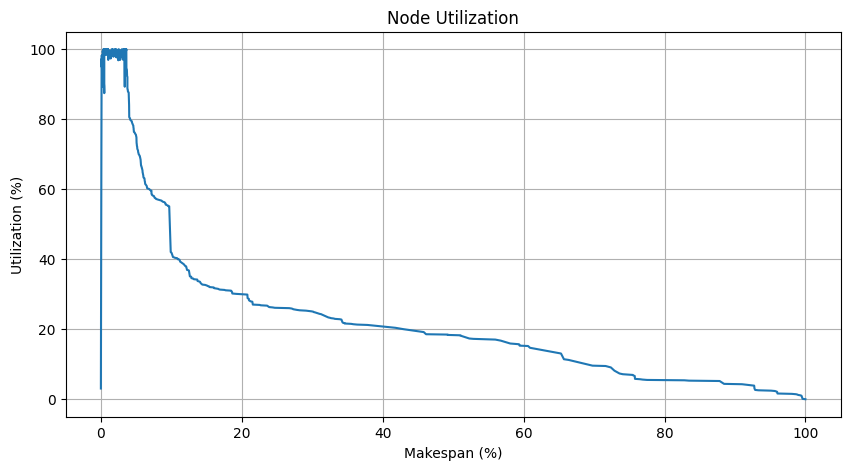

In [34]:
plot_utilization(util_heavy_sjf)

In [35]:
queue_heavy_sjf = queue_size_over_time(df)

Grafico salvato in: images/1800x980/util_vs_queue_M2.png


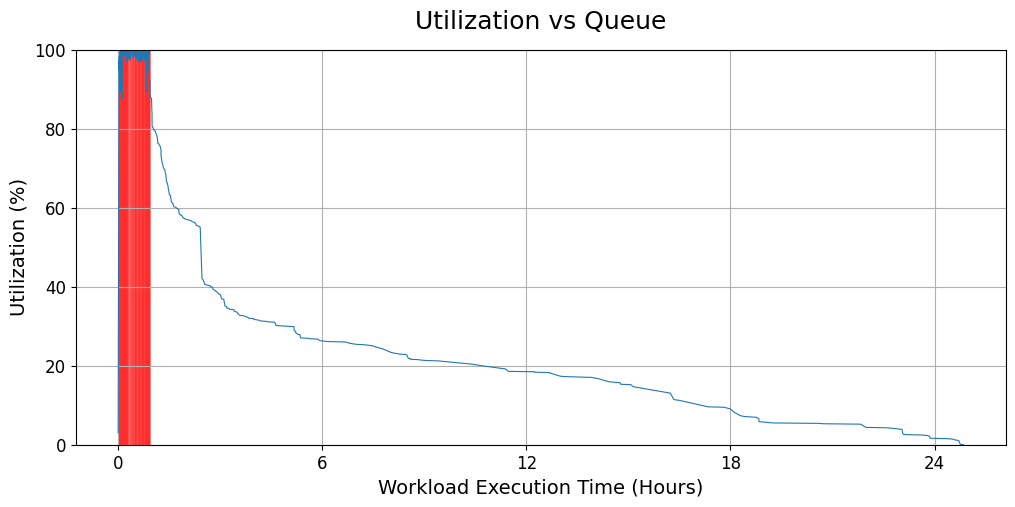

In [48]:
plot_utilization_with_queue_bands(util_heavy_sjf, queue_heavy_sjf, image_path="images/1800x980/util_vs_queue_M2.png")

## Normal

In [12]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/pm100/pm100.swf',
    header=None,
    sep='\t'
)

workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memo§ry", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

workload_df.columns = workload_column_names

# Rename for consistency
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})

### SJF

In [13]:
# =========================================================
# LOAD EXECUTION ORDER AND MERGE WITH WORKLOAD
# =========================================================

column_names = ['n', 'job_id', 'submit_time', 'start_time', 'end_time', 'wtime', 'rtime', 'slowdown', 'nodes']

sim_start_time = 1600210177
filepath = 'queues/pm100/66000x980/pm100_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

# Merge runtime info
df = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)

df = df.sort_values("start_time").reset_index(drop=True)
df = df[column_names]

In [14]:
util_normal_sjf = node_utilization(df)

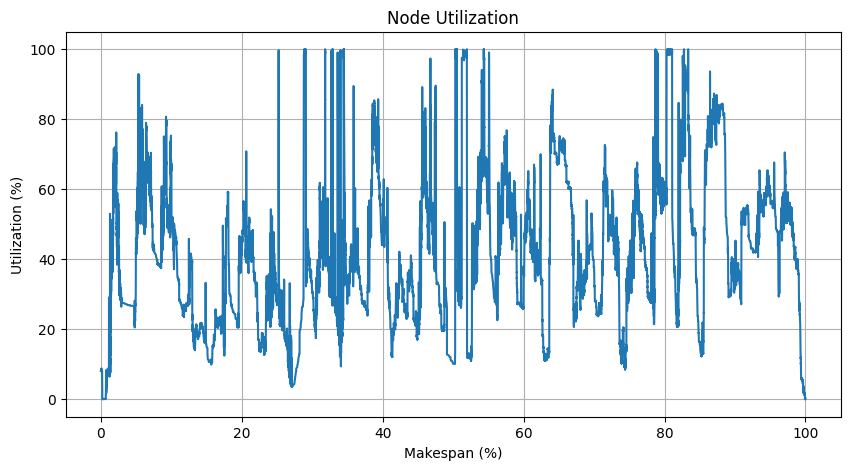

In [15]:
plot_utilization(util_normal_sjf)

In [16]:
queue_normal_sjf = queue_size_over_time(df)

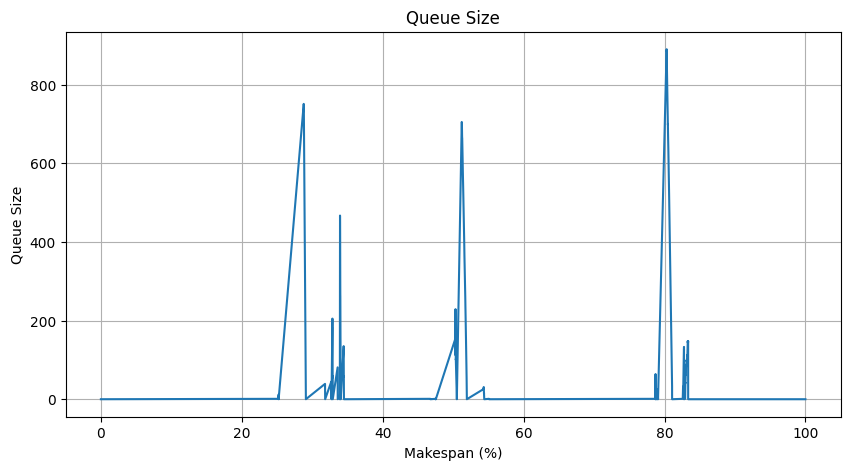

In [17]:
plot_queue(queue_normal_sjf)

Grafico salvato in: images/66000x980/util_vs_queue_M1.png


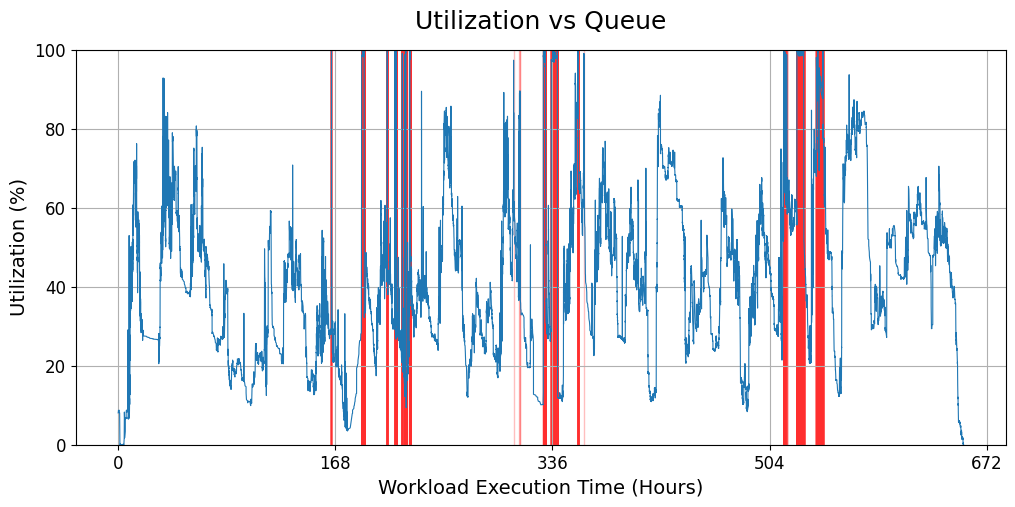

In [49]:
plot_utilization_with_queue_bands(util_normal_sjf, queue_normal_sjf, image_path="images/66000x980/util_vs_queue_M1.png")

In [19]:
len(df[df["wtime"] > 0])

4396

In [20]:
len(df[df["wtime"] > 5])

4384

## Combined Plot

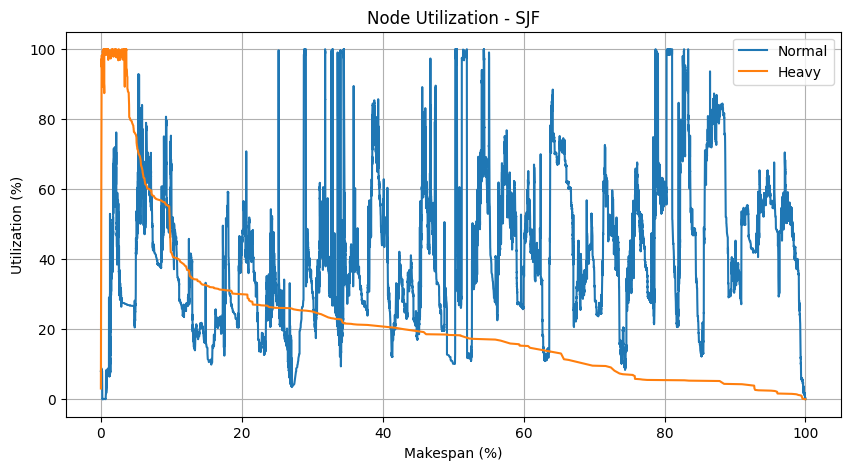

In [21]:
results = [
    util_normal_sjf,
    util_heavy_sjf
]

labels = [
    "Normal",
    "Heavy"
]

plot_utilization_all(results, labels,  title="Node Utilization - SJF")

## Average and Peak Node Utilization

In [22]:
print("Normal - SJF =", np.mean(util_normal_sjf['node_utilization']))
print("Heavy - SJF  =", np.mean(util_heavy_sjf['node_utilization']))

Normal - SJF = 0.4561994550304101
Heavy - SJF  = 0.7810030771407349


In [23]:
print("Normal - SJF =", max(util_normal_sjf['node_utilization']))
print("Heavy - SJF  =", max(util_heavy_sjf['node_utilization']))

Normal - SJF = 1.0
Heavy - SJF  = 1.0
